# GRU + Attention Training for Heatwave Risk (Pakistan)

This notebook trains the production **GRU + attention** model for multi-class `risk_label` prediction using temporal sequences from `df_model_forecast.csv`.

Scope:
- Single model: **GRU_Attn**
- Primary metric: **Validation Macro F1**
- Final outputs: test metrics, confusion matrix, saliency, and `models/gru_attn_best.pkl`

In [1]:
# Local project notebook: no Colab drive mount needed.

Mounted at /content/drive


In [2]:
# If needed, install deep learning dependencies once.
# Uncomment and run if torch is not installed.
# %pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

import os
import random
import math
from dataclasses import dataclass
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [3]:
# Reproducibility and device setup
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Safer deterministic behavior when available.
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

@dataclass
class Config:
    data_path: str = "../data/processed/df_model_forecast.csv"  # base table with target
    humidity_path: str = "../data/raw/pakistan_humidity_daily.csv"
    ndvi_path: str = "../data/raw/pakistan_ndvi_monthly.csv"
    merged_weather_scaled_path: str = "../data/processed/pakistan_weather_merged_scaled.csv"
    city_col: str = "city"
    date_col: str = "date"
    target_col: str = "risk_label"
    train_end_year: int = 2015
    val_end_year: int = 2019
    seq_len: int = 12
    batch_size: int = 32
    hidden_dim: int = 64
    embed_dim: int = 8
    num_layers: int = 2
    dropout: float = 0.25
    lr: float = 3e-4
    weight_decay: float = 1e-4
    epochs: int = 80
    patience: int = 12
    max_grad_norm: float = 1.0

CFG = Config()

Using device: cpu


In [10]:
df.info()
cf.info()
bf.info()
gf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4105 entries, 0 to 4104
Data columns (total 43 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   city               4105 non-null   object 
 1   year               4105 non-null   int64  
 2   month              4105 non-null   int64  
 3   tavg_mean          4105 non-null   float64
 4   tavg_max           4105 non-null   float64
 5   tmin_mean          3926 non-null   float64
 6   tmin_min           3926 non-null   float64
 7   tmax_mean          4105 non-null   float64
 8   tmax_max           4105 non-null   float64
 9   prcp_sum           4105 non-null   float64
 10  prcp_mean          3487 non-null   float64
 11  wspd_mean          1726 non-null   float64
 12  wspd_max           1726 non-null   float64
 13  pres_mean          607 non-null    float64
 14  tsun_mean          0 non-null      float64
 15  tsun_sum           4105 non-null   float64
 16  n_days             4105 

In [4]:
# Load and unify multi-source dataset (base + humidity + NDVI + optional merged weather file)
# 1) Drop all-NaN / all-zero numeric columns on each source before merge.
# 2) After merge: report missingness, drop merged columns that are still all-NaN or all-zero,
#    then train-median impute only columns with partial missingness (no leakage).


def _drop_uninformative_numeric_cols(frame: pd.DataFrame, key_cols: set) -> pd.DataFrame:
    """Drop numeric columns that are entirely NaN or entirely 0 (no variance). Keeps key_cols."""
    out = frame.copy()
    num_cols = out.select_dtypes(include=[np.number]).columns.tolist()
    drop_list = []
    for c in num_cols:
        if c in key_cols:
            continue
        s = pd.to_numeric(out[c], errors="coerce")
        if s.notna().sum() == 0:
            drop_list.append(c)
            continue
        if (s.fillna(0) == 0).all():
            drop_list.append(c)
    if drop_list:
        out = out.drop(columns=drop_list, errors="ignore")
        print(f"  Dropped uninformative numeric cols: {drop_list}")
    return out


# Base table (contains target and existing engineered features)
df = pd.read_csv(CFG.data_path)
if CFG.date_col in df.columns:
    df[CFG.date_col] = pd.to_datetime(df[CFG.date_col])
else:
    year_col = "year"
    month_col = "month"
    if year_col in df.columns and month_col in df.columns:
        df[CFG.date_col] = pd.to_datetime(dict(year=df[year_col], month=df[month_col], day=1))
    else:
        raise ValueError("No date/year-month columns found in base dataset.")

required_cols = {CFG.city_col, CFG.target_col, CFG.date_col}
missing_required = required_cols - set(df.columns)
if missing_required:
    raise ValueError(f"Missing required columns in base dataset: {missing_required}")

# Harmonize city name type early for safer joins.
df[CFG.city_col] = df[CFG.city_col].astype(str).str.strip()

# Year column for train-only imputation after merges
if "year" not in df.columns:
    df["year"] = df[CFG.date_col].dt.year
if "month" not in df.columns:
    df["month"] = df[CFG.date_col].dt.month
train_mask_early = df["year"] <= CFG.train_end_year

# --- Humidity daily -> monthly aggregation ---
if os.path.exists(CFG.humidity_path):
    hum = pd.read_csv(CFG.humidity_path)
    hum["time"] = pd.to_datetime(hum["time"], errors="coerce")
    hum = hum.dropna(subset=["time", "city"])
    hum["city"] = hum["city"].astype(str).str.strip()
    hum["year"] = hum["time"].dt.year
    hum["month"] = hum["time"].dt.month

    hum_cols = [c for c in ["rh_avg", "rh_max", "rh_min", "prcp", "et0"] if c in hum.columns]
    hum = _drop_uninformative_numeric_cols(hum, key_cols=set())
    hum_cols = [c for c in hum_cols if c in hum.columns]
    if hum_cols:
        hum_agg = hum.groupby(["city", "year", "month"], as_index=False)[hum_cols].mean()
        hum_agg = _drop_uninformative_numeric_cols(hum_agg, key_cols={"city", "year", "month"})
        hum_agg = hum_agg.rename(columns={c: f"hum_{c}" for c in hum_cols if c in hum_agg.columns})

        df = df.merge(
            hum_agg,
            how="left",
            left_on=[CFG.city_col, "year", "month"],
            right_on=["city", "year", "month"],
        )
        if "city" in df.columns and CFG.city_col != "city":
            df = df.drop(columns=["city"])

# --- NDVI monthly ---
if os.path.exists(CFG.ndvi_path):
    ndvi = pd.read_csv(CFG.ndvi_path)
    ndvi["time"] = pd.to_datetime(ndvi["time"], errors="coerce")
    ndvi = ndvi.dropna(subset=["time", "city"])
    ndvi["city"] = ndvi["city"].astype(str).str.strip()
    ndvi["year"] = ndvi["time"].dt.year
    ndvi["month"] = ndvi["time"].dt.month

    ndvi = _drop_uninformative_numeric_cols(ndvi, key_cols=set())
    if "ndvi" in ndvi.columns:
        ndvi_m = ndvi.groupby(["city", "year", "month"], as_index=False)["ndvi"].mean()
        ndvi_m = _drop_uninformative_numeric_cols(ndvi_m, key_cols={"city", "year", "month"})
        if "ndvi" in ndvi_m.columns:
            ndvi_m = ndvi_m.rename(columns={"ndvi": "ndvi_monthly"})
            df = df.merge(
                ndvi_m,
                how="left",
                left_on=[CFG.city_col, "year", "month"],
                right_on=["city", "year", "month"],
            )
            if "city" in df.columns and CFG.city_col != "city":
                df = df.drop(columns=["city"])

# --- Optional processed merged weather file daily -> monthly ---
if os.path.exists(CFG.merged_weather_scaled_path):
    wm = pd.read_csv(CFG.merged_weather_scaled_path)
    if {"time", "city"}.issubset(set(wm.columns)):
        wm["time"] = pd.to_datetime(wm["time"], errors="coerce")
        wm = wm.dropna(subset=["time", "city"])
        wm["city"] = wm["city"].astype(str).str.strip()
        wm["year"] = wm["time"].dt.year
        wm["month"] = wm["time"].dt.month

        wm = _drop_uninformative_numeric_cols(wm, key_cols=set())
        wm_candidate_cols = [
            c for c in ["rh_avg_scaled", "prcp_scaled", "et0_scaled", "rh_avg", "prcp", "et0"] if c in wm.columns
        ]
        if wm_candidate_cols:
            wm_m = wm.groupby(["city", "year", "month"], as_index=False)[wm_candidate_cols].mean()
            wm_m = _drop_uninformative_numeric_cols(wm_m, key_cols={"city", "year", "month"})
            wm_m = wm_m.rename(columns={c: f"wm_{c}" for c in wm_candidate_cols if c in wm_m.columns})
            df = df.merge(
                wm_m,
                how="left",
                left_on=[CFG.city_col, "year", "month"],
                right_on=["city", "year", "month"],
            )
            if "city" in df.columns and CFG.city_col != "city":
                df = df.drop(columns=["city"])

# --- Post-merge: missingness report, drop all-NaN / all-zero feature cols, partial train-median impute ---
exclude_meta = {
    CFG.target_col,
    CFG.city_col,
    CFG.date_col,
    "year",
    "month",
    "risk_lag_1", "risk_lag_3", "risk_lag_6",
}
numeric_after = df.select_dtypes(include=[np.number]).columns.tolist()
candidate_features = [c for c in numeric_after if c not in exclude_meta]

na_counts = df[candidate_features].isna().sum()
na_cols = na_counts[na_counts > 0]
print("\n--- Missing values after merge (column -> count) ---")
if len(na_cols) == 0:
    print("None.")
else:
    print(na_cols.sort_values(ascending=False).to_string())

# Drop merged numeric columns that are still entirely NaN or entirely 0
drop_after = []
for c in candidate_features:
    s = pd.to_numeric(df[c], errors="coerce")
    if s.notna().sum() == 0:
        drop_after.append(c)
    elif (s.fillna(0) == 0).all():
        drop_after.append(c)
if drop_after:
    df = df.drop(columns=drop_after, errors="ignore")
    print(f"\nDropped post-merge uninformative cols: {drop_after}")

# Recompute candidate feature names after drops
numeric_after = df.select_dtypes(include=[np.number]).columns.tolist()
candidate_features = [c for c in numeric_after if c not in exclude_meta]

# Partial missingness: train-median impute (same rule as next cell; applied here for merge-time gaps only)
train_med = df.loc[train_mask_early, candidate_features].median(numeric_only=True)
for c in candidate_features:
    if df[c].isna().any() and not df[c].isna().all():
        m = train_med.get(c, np.nan)
        if pd.isna(m):
            m = 0.0
        df[c] = df[c].fillna(m)

# Final missing check on numeric feature candidates
numeric_after = df.select_dtypes(include=[np.number]).columns.tolist()
candidate_features = [c for c in numeric_after if c not in exclude_meta]
still_na = df[candidate_features].isna().sum()
still_na = still_na[still_na > 0]
print("\n--- Missing values after train-median partial impute ---")
if len(still_na) == 0:
    print("None (or only non-numeric columns remain NA).")
else:
    print(still_na.to_string())
    # Remaining NA (e.g. all-NaN column not dropped): fill 0 for stability
    for c in still_na.index.tolist():
        df[c] = df[c].fillna(0.0)

# Keep only numeric feature columns and drop leakage-prone / metadata columns.
exclude_cols = {
    CFG.target_col,
    CFG.city_col,
    CFG.date_col,
    "year",
    "month",
    "risk_lag_1", "risk_lag_3", "risk_lag_6",
}

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c not in exclude_cols]

print(f"\nRows: {len(df):,}")
print(f"Cities: {df[CFG.city_col].nunique()}")
print(f"Classes: {sorted(df[CFG.target_col].dropna().unique().tolist())}")
print(f"Feature count after multi-source merge: {len(feature_cols)}")
print("Example added features:", [c for c in feature_cols if c.startswith(("hum_", "ndvi_", "wm_"))][:20])
print(feature_cols[:25])

  Dropped uninformative numeric cols: ['wdir', 'wpgt', 'tsun']

--- Missing values after merge (column -> count) ---
tsun_mean       4105
pres_mean       3498
wspd_max        2379
wspd_mean       2379
ndvi_monthly    2206
hum_rh_max      1117
hum_rh_min      1117
hum_prcp        1117
hum_rh_avg      1117
hum_et0         1117
prcp_mean        618
tmin_min         179
tmin_mean        179

Dropped post-merge uninformative cols: ['tsun_mean', 'tsun_sum']

--- Missing values after train-median partial impute ---
None (or only non-numeric columns remain NA).

Rows: 4,105
Cities: 7
Classes: [0, 1, 2, 3]
Feature count after multi-source merge: 46
Example added features: ['hum_rh_avg', 'hum_rh_max', 'hum_rh_min', 'hum_prcp', 'hum_et0', 'ndvi_monthly', 'wm_rh_avg_scaled', 'wm_prcp_scaled', 'wm_et0_scaled', 'wm_rh_avg', 'wm_prcp', 'wm_et0']
['tavg_mean', 'tavg_max', 'tmin_mean', 'tmin_min', 'tmax_mean', 'tmax_max', 'prcp_sum', 'prcp_mean', 'wspd_mean', 'wspd_max', 'pres_mean', 'n_days', 'pop_den

In [5]:
# Build city mappings, time split, and robust scaling/imputation

df = df.sort_values([CFG.city_col, CFG.date_col]).reset_index(drop=True)

# Ensure target is numeric and valid.
df[CFG.target_col] = pd.to_numeric(df[CFG.target_col], errors="coerce")
df = df.dropna(subset=[CFG.target_col]).copy()
df[CFG.target_col] = df[CFG.target_col].astype(int)

df["year_tmp"] = df[CFG.date_col].dt.year
train_mask = df["year_tmp"] <= CFG.train_end_year
val_mask = (df["year_tmp"] > CFG.train_end_year) & (df["year_tmp"] <= CFG.val_end_year)
test_mask = df["year_tmp"] > CFG.val_end_year

city_to_idx = {c: i for i, c in enumerate(sorted(df[CFG.city_col].unique()))}
df["city_idx"] = df[CFG.city_col].map(city_to_idx)
num_cities = len(city_to_idx)
num_classes = int(df[CFG.target_col].nunique())

# Convert features to numeric, remove inf, and impute with train medians only.
df[feature_cols] = df[feature_cols].apply(pd.to_numeric, errors="coerce")
df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], np.nan)

train_feature_medians = df.loc[train_mask, feature_cols].median(numeric_only=True)
df[feature_cols] = df[feature_cols].fillna(train_feature_medians)
# If a column is fully missing in train, median can be NaN; force safe fallback.
df[feature_cols] = df[feature_cols].fillna(0.0)

scaler = StandardScaler()
scaler.fit(df.loc[train_mask, feature_cols])
df[feature_cols] = scaler.transform(df[feature_cols])
df[feature_cols] = np.nan_to_num(df[feature_cols].to_numpy(), nan=0.0, posinf=0.0, neginf=0.0)

print("Train rows:", int(train_mask.sum()))
print("Val rows:", int(val_mask.sum()))
print("Test rows:", int(test_mask.sum()))
print("Num cities:", num_cities, "Num classes:", num_classes)
print("Any non-finite in features:", ~np.isfinite(df[feature_cols].to_numpy()).all())

Train rows: 3475
Val rows: 306
Test rows: 324
Num cities: 7 Num classes: 4
Any non-finite in features: False


In [6]:
# Dataset utilities
class SequenceDataset(Dataset):
    def __init__(self, X_seq, city_seq, y_seq):
        self.X = torch.tensor(X_seq, dtype=torch.float32)
        self.city = torch.tensor(city_seq, dtype=torch.long)
        self.y = torch.tensor(y_seq, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.city[idx], self.y[idx]


def make_sequences(df_part: pd.DataFrame, feature_cols: List[str], seq_len: int):
    X_all, city_all, y_all = [], [], []

    for _, g in df_part.groupby(CFG.city_col):
        g = g.sort_values(CFG.date_col)
        X = g[feature_cols].values
        y = g[CFG.target_col].values.astype(int)
        city_idx = g["city_idx"].values.astype(int)

        if len(g) < seq_len:
            continue

        for t in range(seq_len - 1, len(g)):
            X_all.append(X[t - seq_len + 1:t + 1])
            city_all.append(city_idx[t])
            y_all.append(y[t])

    return np.array(X_all), np.array(city_all), np.array(y_all)


def build_loaders(df: pd.DataFrame, feature_cols: List[str], seq_len: int, batch_size: int):
    train_df = df[df["year_tmp"] <= CFG.train_end_year].copy()
    val_df = df[(df["year_tmp"] > CFG.train_end_year) & (df["year_tmp"] <= CFG.val_end_year)].copy()
    test_df = df[df["year_tmp"] > CFG.val_end_year].copy()

    X_train, c_train, y_train = make_sequences(train_df, feature_cols, seq_len)
    X_val, c_val, y_val = make_sequences(val_df, feature_cols, seq_len)
    X_test, c_test, y_test = make_sequences(test_df, feature_cols, seq_len)

    train_ds = SequenceDataset(X_train, c_train, y_train)
    val_ds = SequenceDataset(X_val, c_val, y_val)
    test_ds = SequenceDataset(X_test, c_test, y_test)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader, y_train, y_val, y_test

In [7]:
# Model architectures
class AttentionPool(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.score = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x: (B, T, H)
        w = torch.softmax(self.score(x).squeeze(-1), dim=1)  # (B, T)
        context = torch.sum(x * w.unsqueeze(-1), dim=1)      # (B, H)
        return context


class RNNAttentionClassifier(nn.Module):
    def __init__(self, input_dim, num_cities, num_classes, rnn_type="gru", hidden_dim=64, num_layers=2, dropout=0.25, embed_dim=8):
        super().__init__()
        self.city_emb = nn.Embedding(num_cities, embed_dim)

        rnn_cls = nn.GRU if rnn_type.lower() == "gru" else nn.LSTM
        self.rnn = rnn_cls(
            input_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=True,
        )
        self.attn = AttentionPool(hidden_dim * 2)
        self.head = nn.Sequential(
            nn.Linear(hidden_dim * 2 + embed_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x, city_idx):
        out, _ = self.rnn(x)
        ctx = self.attn(out)
        city_vec = self.city_emb(city_idx)
        logits = self.head(torch.cat([ctx, city_vec], dim=1))
        return logits


class TCNClassifier(nn.Module):
    def __init__(self, input_dim, num_cities, num_classes, hidden_dim=64, dropout=0.25, embed_dim=8):
        super().__init__()
        self.city_emb = nn.Embedding(num_cities, embed_dim)
        self.net = nn.Sequential(
            nn.Conv1d(input_dim, hidden_dim, kernel_size=3, padding=2, dilation=1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=4, dilation=2),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_dim + embed_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x, city_idx):
        # x: (B, T, F) -> (B, F, T)
        x = x.transpose(1, 2)
        feat = self.net(x)
        pooled = feat.mean(dim=2)
        city_vec = self.city_emb(city_idx)
        logits = self.head(torch.cat([pooled, city_vec], dim=1))
        return logits


class TransformerClassifier(nn.Module):
    def __init__(self, input_dim, num_cities, num_classes, hidden_dim=64, num_layers=2, nhead=4, dropout=0.25, embed_dim=8):
        super().__init__()
        self.city_emb = nn.Embedding(num_cities, embed_dim)
        self.proj = nn.Linear(input_dim, hidden_dim)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=nhead,
            dropout=dropout,
            batch_first=True,
            dim_feedforward=hidden_dim * 2,
            activation="gelu",
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.head = nn.Sequential(
            nn.Linear(hidden_dim + embed_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x, city_idx):
        z = self.proj(x)
        z = self.encoder(z)
        pooled = z.mean(dim=1)
        city_vec = self.city_emb(city_idx)
        logits = self.head(torch.cat([pooled, city_vec], dim=1))
        return logits

In [8]:
# Training and evaluation helpers

def run_epoch(model, loader, criterion, optimizer=None):
    train = optimizer is not None
    model.train() if train else model.eval()

    losses = []
    all_preds = []
    all_true = []
    skipped_batches = 0

    for xb, cb, yb in loader:
        xb, cb, yb = xb.to(device), cb.to(device), yb.to(device)

        # Hard guard against malformed batch values.
        if not torch.isfinite(xb).all():
            skipped_batches += 1
            continue

        with torch.set_grad_enabled(train):
            logits = model(xb, cb)
            if not torch.isfinite(logits).all():
                skipped_batches += 1
                continue

            loss = criterion(logits, yb)
            if not torch.isfinite(loss):
                skipped_batches += 1
                continue

            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.max_grad_norm)
                optimizer.step()

        preds = torch.argmax(logits, dim=1)
        losses.append(loss.item())
        all_preds.extend(preds.detach().cpu().numpy())
        all_true.extend(yb.detach().cpu().numpy())

    if len(all_true) == 0:
        return np.nan, 0.0, 0.0, np.array([]), np.array([]), skipped_batches

    macro_f1 = f1_score(all_true, all_preds, average="macro", zero_division=0)
    weighted_f1 = f1_score(all_true, all_preds, average="weighted", zero_division=0)
    avg_loss = float(np.mean(losses)) if len(losses) > 0 else np.nan
    return avg_loss, macro_f1, weighted_f1, np.array(all_true), np.array(all_preds), skipped_batches


def train_model(model_name, model, train_loader, val_loader, class_weights):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device), label_smoothing=0.05)
    optimizer = torch.optim.AdamW(model.parameters(), lr=CFG.lr, weight_decay=CFG.weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=4)

    best_state = None
    best_val_f1 = -1
    wait = 0
    history = []

    for epoch in range(1, CFG.epochs + 1):
        tr_loss, tr_macro, tr_w, _, _, tr_skipped = run_epoch(model, train_loader, criterion, optimizer)
        va_loss, va_macro, va_w, _, _, va_skipped = run_epoch(model, val_loader, criterion, optimizer=None)

        if np.isfinite(va_macro):
            scheduler.step(va_macro)

        history.append({
            "epoch": epoch,
            "train_loss": tr_loss,
            "val_loss": va_loss,
            "train_macro_f1": tr_macro,
            "val_macro_f1": va_macro,
            "train_skipped_batches": tr_skipped,
            "val_skipped_batches": va_skipped,
        })

        if np.isfinite(va_macro) and va_macro > best_val_f1:
            best_val_f1 = va_macro
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        if epoch % 10 == 0 or epoch == 1:
            print(
                f"[{model_name}] Epoch {epoch:03d} | train_macro={tr_macro:.4f} | "
                f"val_macro={va_macro:.4f} | skipped(train/val)={tr_skipped}/{va_skipped}"
            )

        if wait >= CFG.patience:
            print(f"[{model_name}] Early stopped at epoch {epoch}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, pd.DataFrame(history), best_val_f1

In [9]:
# Build loaders and class weights
train_loader, val_loader, test_loader, y_train, y_val, y_test = build_loaders(
    df=df,
    feature_cols=feature_cols,
    seq_len=CFG.seq_len,
    batch_size=CFG.batch_size,
)

if len(y_train) == 0 or len(y_val) == 0 or len(y_test) == 0:
    raise ValueError("One of the sequence splits is empty. Reduce seq_len or check date splits.")

counts = np.bincount(y_train, minlength=num_classes)
weights = counts.sum() / np.maximum(counts, 1)
weights = weights / weights.mean()
class_weights = torch.tensor(weights, dtype=torch.float32)

print("Train sequences:", len(y_train))
print("Val sequences:", len(y_val))
print("Test sequences:", len(y_test))
print("Class counts (train):", counts)
print("Class weights:", class_weights.numpy())

Train sequences: 3398
Val sequences: 229
Test sequences: 247
Class counts (train): [1738  899  483  278]
Class weights: [0.31290576 0.60492796 1.1259425  1.9562238 ]


In [10]:
# Quick label distribution diagnostics
for split_name, y_split in [("train", y_train), ("val", y_val), ("test", y_test)]:
    uniq, cnt = np.unique(y_split, return_counts=True)
    dist = {int(k): int(v) for k, v in zip(uniq, cnt)}
    print(f"{split_name} label distribution:", dist)

# If a split does not contain all classes, macro F1 can be harsh/unstable.
missing_in_train = set(range(num_classes)) - set(np.unique(y_train).tolist())
if missing_in_train:
    print("Warning: classes missing in train split:", missing_in_train)

train label distribution: {0: 1738, 1: 899, 2: 483, 3: 278}
val label distribution: {0: 98, 1: 32, 2: 49, 3: 50}
test label distribution: {0: 96, 1: 56, 2: 44, 3: 51}


In [11]:
# Train and compare candidate models
input_dim = len(feature_cols)

candidates = {
    "GRU_Attn": RNNAttentionClassifier(
        input_dim=input_dim,
        num_cities=num_cities,
        num_classes=num_classes,
        rnn_type="gru",
        hidden_dim=CFG.hidden_dim,
        num_layers=CFG.num_layers,
        dropout=CFG.dropout,
        embed_dim=CFG.embed_dim,
    ),
    "LSTM_Attn": RNNAttentionClassifier(
        input_dim=input_dim,
        num_cities=num_cities,
        num_classes=num_classes,
        rnn_type="lstm",
        hidden_dim=CFG.hidden_dim,
        num_layers=CFG.num_layers,
        dropout=CFG.dropout,
        embed_dim=CFG.embed_dim,
    ),
    "TCN": TCNClassifier(
        input_dim=input_dim,
        num_cities=num_cities,
        num_classes=num_classes,
        hidden_dim=CFG.hidden_dim,
        dropout=CFG.dropout,
        embed_dim=CFG.embed_dim,
    ),
    "Transformer": TransformerClassifier(
        input_dim=input_dim,
        num_cities=num_cities,
        num_classes=num_classes,
        hidden_dim=CFG.hidden_dim,
        num_layers=2,
        nhead=4,
        dropout=CFG.dropout,
        embed_dim=CFG.embed_dim,
    ),
}

results = []
histories = {}
trained_models = {}

for name, model in candidates.items():
    print(f"\n=== Training {name} ===")
    best_model, hist_df, best_val_f1 = train_model(name, model, train_loader, val_loader, class_weights)
    trained_models[name] = best_model
    histories[name] = hist_df
    results.append({"model": name, "best_val_macro_f1": best_val_f1})

results_df = pd.DataFrame(results).sort_values("best_val_macro_f1", ascending=False).reset_index(drop=True)
results_df


=== Training GRU_Attn ===
[GRU_Attn] Epoch 001 | train_macro=0.3523 | val_macro=0.4502 | skipped(train/val)=0/0
[GRU_Attn] Epoch 010 | train_macro=0.9016 | val_macro=0.7170 | skipped(train/val)=0/0
[GRU_Attn] Epoch 020 | train_macro=0.9434 | val_macro=0.8612 | skipped(train/val)=0/0
[GRU_Attn] Epoch 030 | train_macro=0.9665 | val_macro=0.8479 | skipped(train/val)=0/0
[GRU_Attn] Epoch 040 | train_macro=0.9788 | val_macro=0.8262 | skipped(train/val)=0/0
[GRU_Attn] Early stopped at epoch 41

=== Training LSTM_Attn ===
[LSTM_Attn] Epoch 001 | train_macro=0.3064 | val_macro=0.4249 | skipped(train/val)=0/0
[LSTM_Attn] Epoch 010 | train_macro=0.8949 | val_macro=0.8250 | skipped(train/val)=0/0
[LSTM_Attn] Epoch 020 | train_macro=0.9419 | val_macro=0.8158 | skipped(train/val)=0/0
[LSTM_Attn] Epoch 030 | train_macro=0.9658 | val_macro=0.8525 | skipped(train/val)=0/0
[LSTM_Attn] Epoch 040 | train_macro=0.9755 | val_macro=0.8526 | skipped(train/val)=0/0
[LSTM_Attn] Early stopped at epoch 43

=== 

,model,best_val_macro_f1
0,GRU_Attn,0.906831
1,LSTM_Attn,0.879589
2,TCN,0.871994
3,Transformer,0.286878


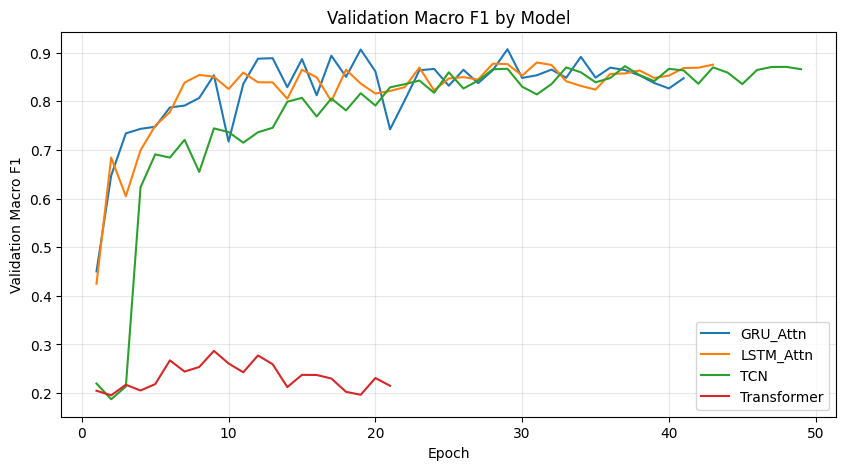

In [12]:
# Plot validation curves
plt.figure(figsize=(10, 5))
for name, hist in histories.items():
    plt.plot(hist["epoch"], hist["val_macro_f1"], label=name)
plt.xlabel("Epoch")
plt.ylabel("Validation Macro F1")
plt.title("Validation Macro F1 by Model")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Best model: GRU_Attn
Test loss: 0.4262
Test macro F1: 0.8869
Test weighted F1: 0.9030
Skipped test batches: 0

Classification Report:

              precision    recall  f1-score   support

           0     0.9592    0.9792    0.9691        96
           1     0.8800    0.7857    0.8302        56
           2     0.7600    0.8636    0.8085        44
           3     0.9592    0.9216    0.9400        51

    accuracy                         0.9028       247
   macro avg     0.8896    0.8875    0.8869       247
weighted avg     0.9057    0.9028    0.9030       247



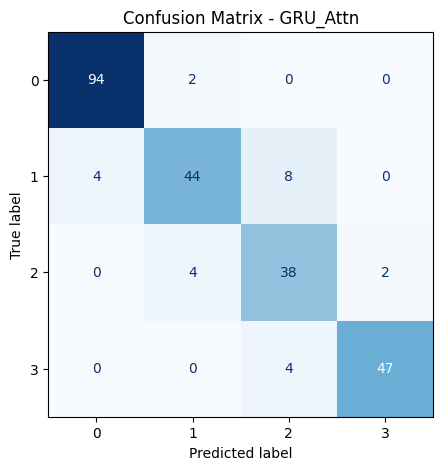

In [13]:
# Final test evaluation on the best validation model
best_name = results_df.iloc[0]["model"]
best_model = trained_models[best_name]

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device), label_smoothing=0.05)
test_loss, test_macro, test_weighted, y_true, y_pred, test_skipped = run_epoch(
    best_model,
    test_loader,
    criterion,
    optimizer=None,
)

print("Best model:", best_name)
print(f"Test loss: {test_loss:.4f}" if np.isfinite(test_loss) else "Test loss: NaN (check skipped batches)")
print(f"Test macro F1: {test_macro:.4f}")
print(f"Test weighted F1: {test_weighted:.4f}")
print("Skipped test batches:", test_skipped)

if len(y_true) == 0:
    raise RuntimeError("No valid test predictions were produced. Check feature quality and NaN handling.")

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, digits=4, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Confusion Matrix - {best_name}")
plt.show()

City-wise performance of best model: GRU_Attn


,city,samples,macro_f1,weighted_f1,accuracy,true_class_dist,pred_class_dist
0,Multan,37,0.964646,0.971881,0.972973,"{0: 13, 1: 3, 2: 5, 3: 16}","{0: 13, 1: 3, 2: 4, 3: 17}"
1,Lahore,37,0.940776,0.945478,0.945946,"{0: 14, 1: 7, 2: 7, 3: 9}","{0: 15, 1: 6, 2: 8, 3: 8}"
2,Peshawar,37,0.908046,0.968934,0.972973,"{0: 15, 1: 6, 2: 2, 3: 14}","{0: 15, 1: 6, 2: 1, 3: 15}"
3,Islamabad,35,0.901347,0.915315,0.914286,"{0: 14, 1: 6, 2: 9, 3: 6}","{0: 13, 1: 6, 2: 11, 3: 5}"
4,Rawalpindi,35,0.891558,0.913395,0.914286,"{0: 14, 1: 6, 2: 9, 3: 6}","{0: 14, 1: 5, 2: 12, 3: 4}"
5,Quetta,29,0.864705,0.896943,0.896552,"{0: 16, 1: 7, 2: 6}","{0: 15, 1: 6, 2: 8}"
6,Karachi,37,0.640282,0.696556,0.702703,"{0: 10, 1: 21, 2: 6}","{0: 13, 1: 18, 2: 6}"


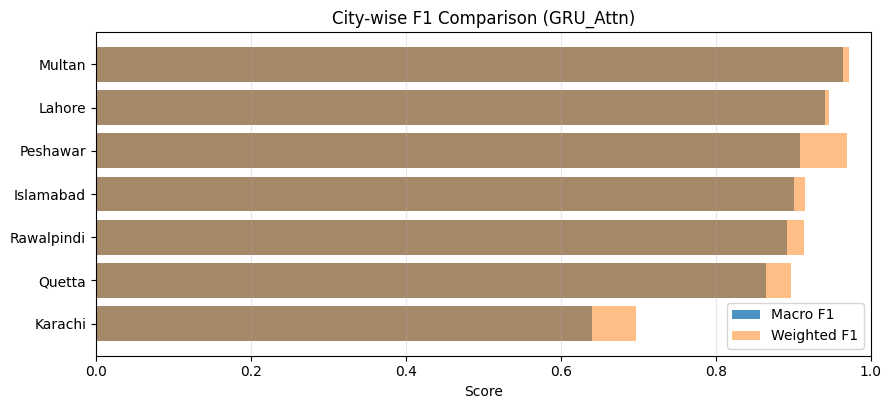

In [14]:
# City-wise comparison for the selected best model

def make_sequences_with_city_name(df_part: pd.DataFrame, feature_cols: List[str], seq_len: int):
    X_all, city_idx_all, city_name_all, y_all = [], [], [], []

    for city_name, g in df_part.groupby(CFG.city_col):
        g = g.sort_values(CFG.date_col)
        X = g[feature_cols].values
        y = g[CFG.target_col].values.astype(int)
        city_idx = g["city_idx"].values.astype(int)

        if len(g) < seq_len:
            continue

        for t in range(seq_len - 1, len(g)):
            X_all.append(X[t - seq_len + 1:t + 1])
            city_idx_all.append(city_idx[t])
            city_name_all.append(city_name)
            y_all.append(y[t])

    return np.array(X_all), np.array(city_idx_all), np.array(city_name_all), np.array(y_all)


def predict_arrays(model, X_np, city_idx_np, batch_size=256):
    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(X_np), batch_size):
            xb = torch.tensor(X_np[i:i+batch_size], dtype=torch.float32, device=device)
            cb = torch.tensor(city_idx_np[i:i+batch_size], dtype=torch.long, device=device)
            logits = model(xb, cb)
            pred = torch.argmax(logits, dim=1).cpu().numpy()
            preds.extend(pred)
    return np.array(preds)


test_df_city = df[df["year_tmp"] > CFG.val_end_year].copy()
Xc, Cc, city_names, yc = make_sequences_with_city_name(test_df_city, feature_cols, CFG.seq_len)

if len(yc) == 0:
    raise RuntimeError("No city-level test sequences found. Try reducing seq_len.")

yp = predict_arrays(best_model, Xc, Cc)

rows = []
for city in sorted(np.unique(city_names)):
    mask = city_names == city
    y_true_city = yc[mask]
    y_pred_city = yp[mask]

    rows.append({
        "city": city,
        "samples": int(mask.sum()),
        "macro_f1": float(f1_score(y_true_city, y_pred_city, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_true_city, y_pred_city, average="weighted", zero_division=0)),
        "accuracy": float((y_true_city == y_pred_city).mean()),
        "true_class_dist": str({int(k): int(v) for k, v in zip(*np.unique(y_true_city, return_counts=True))}),
        "pred_class_dist": str({int(k): int(v) for k, v in zip(*np.unique(y_pred_city, return_counts=True))}),
    })

city_results_df = pd.DataFrame(rows).sort_values("macro_f1", ascending=False).reset_index(drop=True)
print(f"City-wise performance of best model: {best_name}")
display(city_results_df)

# Plot city-wise macro and weighted F1
plot_df = city_results_df.sort_values("macro_f1", ascending=True)
plt.figure(figsize=(10, max(4, len(plot_df) * 0.6)))
plt.barh(plot_df["city"], plot_df["macro_f1"], alpha=0.8, label="Macro F1")
plt.barh(plot_df["city"], plot_df["weighted_f1"], alpha=0.5, label="Weighted F1")
plt.xlabel("Score")
plt.title(f"City-wise F1 Comparison ({best_name})")
plt.xlim(0, 1)
plt.legend()
plt.grid(axis="x", alpha=0.3)
plt.show()

In [15]:
# Save best model and metadata
os.makedirs("../models", exist_ok=True)

save_path = "../models/gru_attn_best.pkl"
torch.save({
    "model_name": best_name,
    "model_state_dict": best_model.state_dict(),
    "feature_cols": feature_cols,
    "city_to_idx": city_to_idx,
    "config": CFG.__dict__,
}, save_path)

os.makedirs("../outputs/figures", exist_ok=True)
results_path = "../outputs/figures/gru_training_summary.csv"
results_df.to_csv(results_path, index=False)

print("Saved best model to:", save_path)
print("Saved training summary to:", results_path)

Saved best model to: /content/drive/MyDrive/models/deep_learning/gru_attn_best.pkl
Saved comparison table to: /content/drive/MyDrive/models/deep_learning/dl_model_comparison.csv
